## Significant Lake Effect Snowstorm 

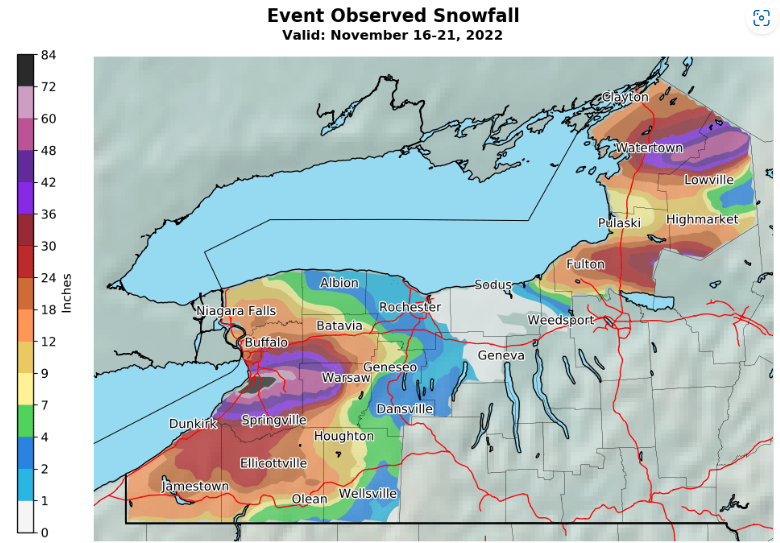

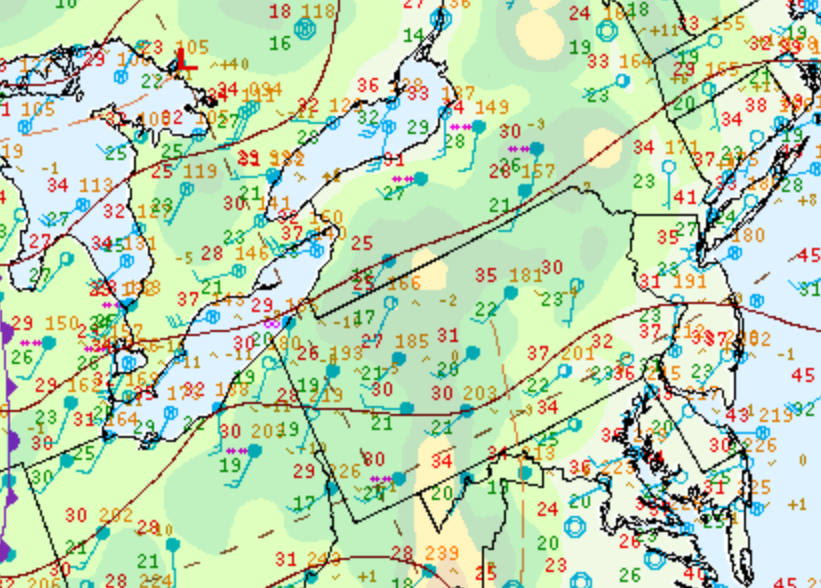

## Preliminary Thoughts
#### What are you thinking of focusing on?
    # We will be focusing on a Lake Erie and The 2022 Nov 16-21 lakw effect snowstorm. 
#### What makes this hazard or application interesting to explore?
    # This hazard is intresting because lake effect snow storms can produce crazy amounts of snow fall in certain areas. 
#### Why might it be useful to quantify threat or impact in this area?
    # It is useful for this area because lake effect snow storms can be very life threating to those who live near the Great Lakes.

## Imported Tools

In [1]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Downloading Data

In [2]:
ds_run = xr.open_dataset("GFS_2022111700.nc")
ds_run

sh: 1: getfattr: not found


<xarray.Dataset> Size: 8MB
Dimensions:            (valid_time: 15, latitude: 41, longitude: 81,
                        isobaricInhPa: 5)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2022-11-17 ... 2022-1...
  * latitude           (latitude) float64 328B 50.0 49.75 49.5 ... 40.25 40.0
  * longitude          (longitude) float64 648B 275.0 275.2 ... 294.8 295.0
  * isobaricInhPa      (isobaricInhPa) float64 40B 1e+03 850.0 700.0 500.0 250.0
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables: (12/14)
    orog               (valid_time, latitude, longitude) float32 199kB ...
    tS                 (valid_time, latitude, longitude) float32 199kB ...
    sit                (valid_time, latitude, longitude) float32 199kB ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    r                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    ...                 ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 996kB ...
    t2m                (valid_time, latitude, longitude) float32 199kB ...
    r2                 (valid_time, latitude, longitude) float32 199kB ...
    aptmp              (valid_time, latitude, longitude) float32 199kB ...
    tp                 (valid_time, latitude, longitude) float32 199kB ...
    prmsl              (valid_time, latitude, longitude) float32 199kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T18:29 GRIB to CDM+CF via cfgrib-0.9.1...

## Generating Map

(<Figure size 1000x800 with 1 Axes>, <GeoAxes: >)

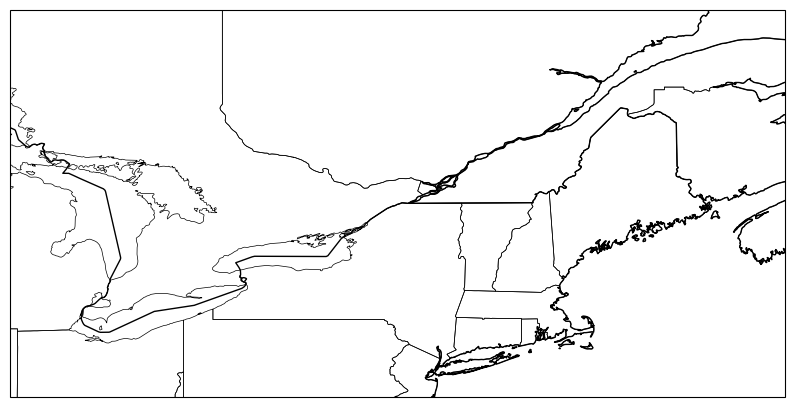

In [3]:
def basemap():
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-85,-65, 40, 50])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    return fig, ax

basemap() # -> Map focused on our area of interest, contains state and country borders

## Map Plots Using Variables

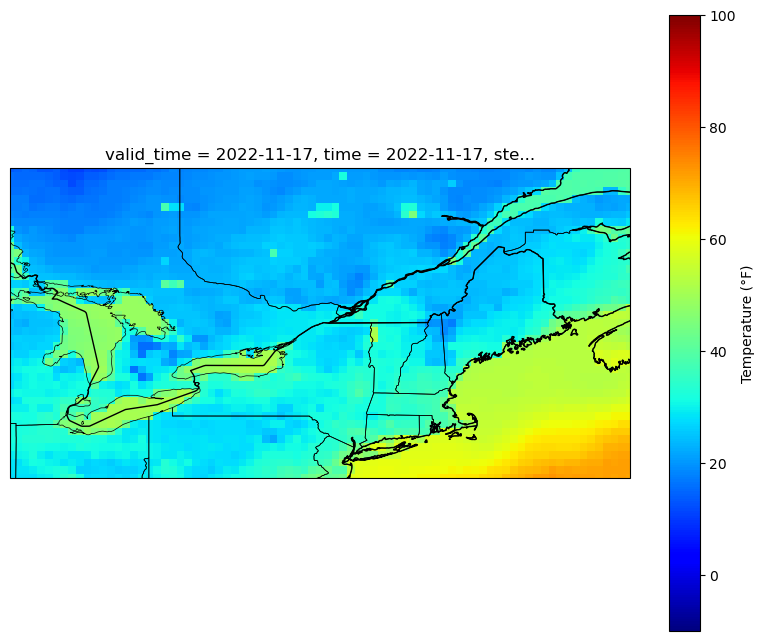

In [4]:
fig, ax = basemap()

temp_sfc = ((ds_run['tS'].isel(valid_time=0) - 273.15) * 9/5) + 32 # -> Converts from Kelvin to Fahrenheit

temp_sfc.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet',
    vmin=-10, vmax=100,
    cbar_kwargs={'label': 'Temperature (°F)'}
)
# -> A surface temperature map

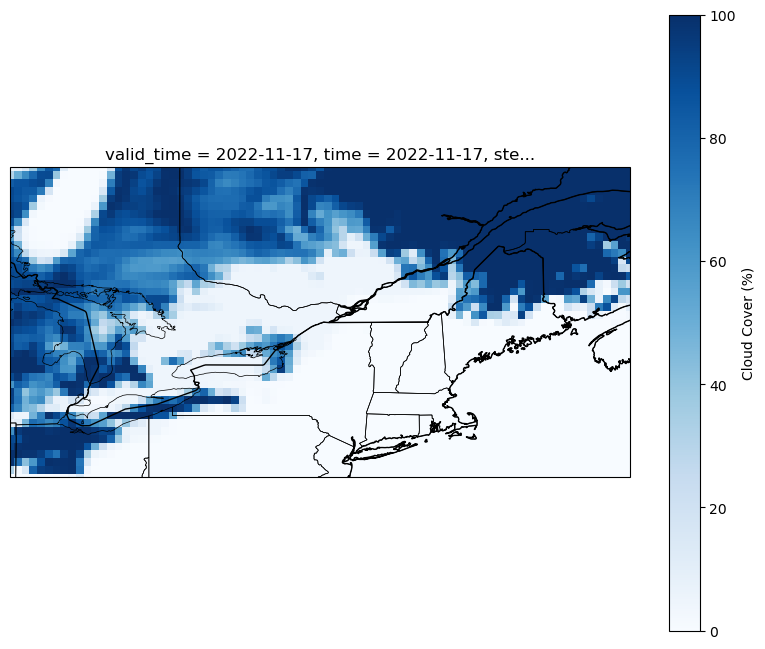

In [5]:
fig, ax = basemap()

tcc = ds_run['tcc'].sel(isobaricInhPa=700).isel(valid_time=0)

tcc.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Cloud Cover (%)'}
)
# -> A cloud cover map

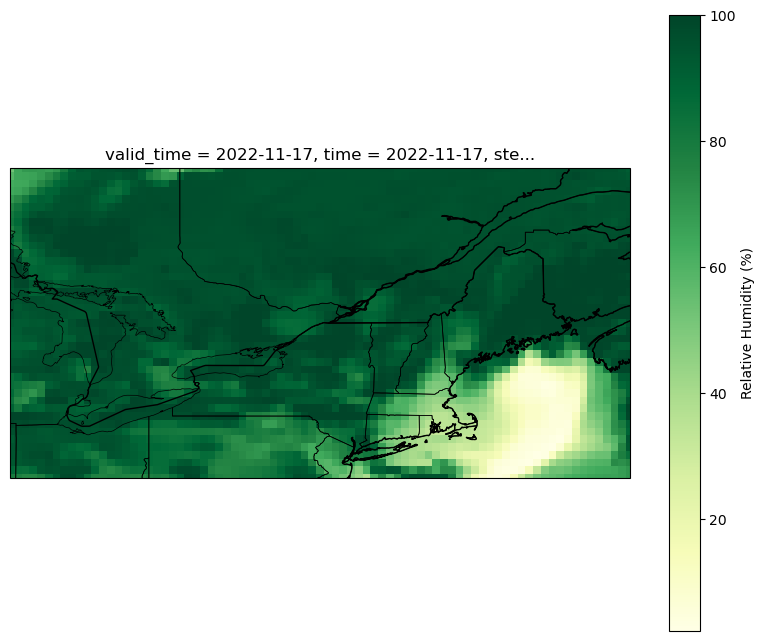

In [6]:
fig, ax = basemap()

RH = ds_run['r'].sel(isobaricInhPa=850).isel(valid_time=0)

RH.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    cbar_kwargs={'label': 'Relative Humidity (%)'}
)
# -> A relative humidity map

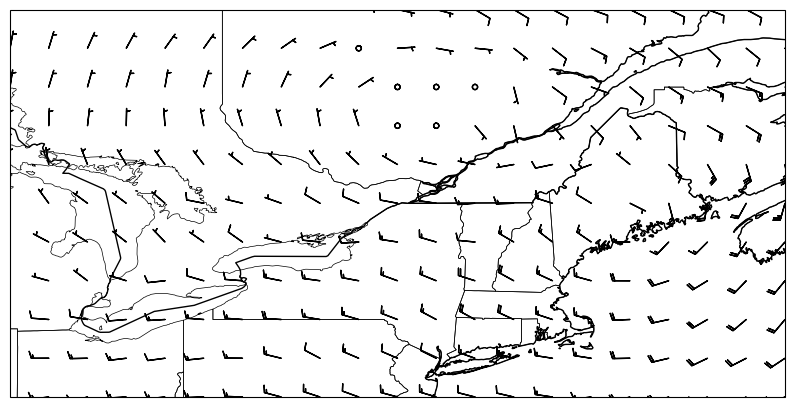

In [7]:
fig, ax = basemap()

u = ds_run['u'].sel(isobaricInhPa=850).isel(valid_time=0)
v = ds_run['v'].sel(isobaricInhPa=850).isel(valid_time=0)

skip = 4  # increase this number to reduce density

ax.barbs(
    ds_run.longitude.values[::skip],
    ds_run.latitude.values[::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
    length=5
)
# -> Wind barbs in the selected area

## Map Plot Using a Calculated Variable

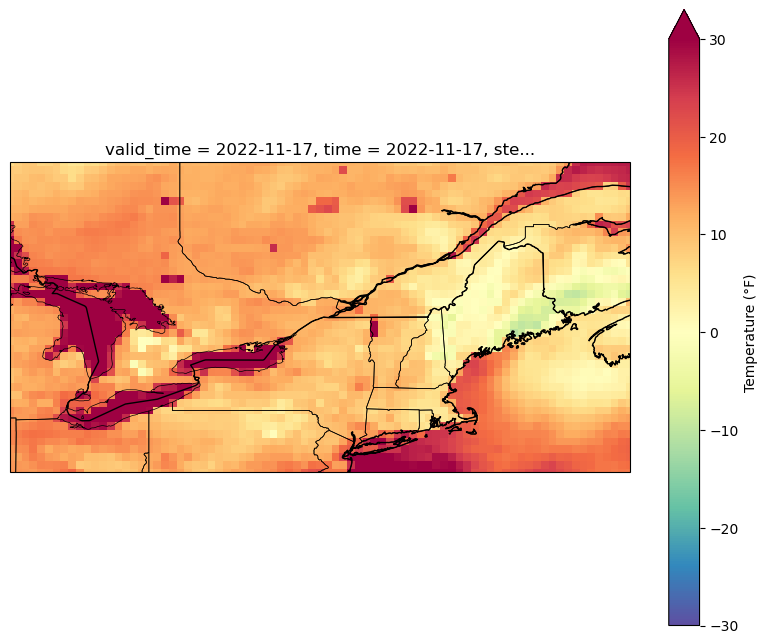

In [8]:
fig, ax = basemap()

delta_T = ((((ds_run["tS"] - 273.15) * 9/5) + 32) - (((ds_run["t"].sel(isobaricInhPa=850) - 273.15) * 9/5) + 32)).isel(valid_time=0)
# -> Converts the difference in surface temperatures and temperatures at 850hPa from Kelvin to Fahrenheit

delta_T.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Spectral_r',
    vmin=-30, vmax=30,
    cbar_kwargs={'label': 'Temperature (°F)'}
)
# -> A temperature difference map